# 02 — Moving Averages and Lags

**Hour 2, 80–90 min: Turning patterns into features**

In Notebook 01 we SAW trend and seasonality. Now we build the two most important beginner
tools for actually USING that information: moving averages (for smoothing/understanding) and
lag features (for feeding time-dependency into a model).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (11, 5)

df = pd.read_csv("../data/bank_cash_withdrawal_timeseries.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,WithdrawalAmount,DayOfWeek,IsWeekend,Month,IsHolidayIndicator
0,2023-01-01,5202245,Sunday,1,1,1
1,2023-01-02,24686212,Monday,0,1,0
2,2023-01-03,25553319,Tuesday,0,1,0
3,2023-01-04,19900094,Wednesday,0,1,0
4,2023-01-05,18711187,Thursday,0,1,0


## Moving Average

**What are we doing?** Computing a 7-day moving average — each day's smoothed value is the
average of that day and the 6 days before it.

**Why?** To smooth out short-term, day-to-day fluctuations so the bigger pattern (trend +
weekly rhythm) is easier to see.

In [2]:
df["MA_7"] = df["WithdrawalAmount"].rolling(window=7).mean()
df[["Date", "WithdrawalAmount", "MA_7"]].head(10)

,Date,WithdrawalAmount,MA_7
0,2023-01-01,5202245,NaN
1,2023-01-02,24686212,NaN
2,2023-01-03,25553319,NaN
3,2023-01-04,19900094,NaN
4,2023-01-05,18711187,NaN
5,2023-01-06,22528965,NaN
6,2023-01-07,22234478,1.983093e+07
7,2023-01-08,10782889,2.062816e+07
8,2023-01-09,20128770,1.997710e+07
9,2023-01-10,18783182,1.900994e+07


**What does `rolling()` do?** It creates a "window" that slides one row at a time down the
column, and `window=7` tells it to include the current row plus the 6 rows before it.

**Why are the first few rows of `MA_7` missing (`NaN`)?** For the very first row, there aren't
6 previous days to average yet — pandas can't compute a full 7-day window until day 7. This is
completely normal and expected.

In [3]:
missing = df["MA_7"].isna().sum()
print(f"{missing} rows have a missing MA_7 value (exactly window - 1 = 6, as expected).")

6 rows have a missing MA_7 value (exactly window - 1 = 6, as expected).


### Visualize: original vs. moving average

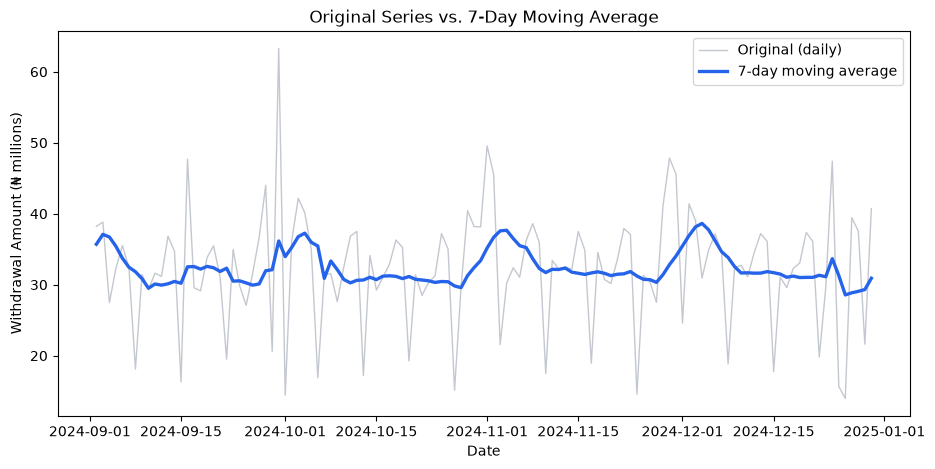

In [4]:
recent = df.iloc[-120:]

fig, ax = plt.subplots()
ax.plot(recent["Date"], recent["WithdrawalAmount"] / 1e6, color="#9CA3AF", alpha=0.6, linewidth=1, label="Original (daily)")
ax.plot(recent["Date"], recent["MA_7"] / 1e6, color="#2563EB", linewidth=2.4, label="7-day moving average")
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Original Series vs. 7-Day Moving Average")
ax.legend()
plt.show()

**Business perspective:** A moving average is great for UNDERSTANDING the data — spotting the trend, communicating it to non-technical stakeholders — but on its own it does not automatically forecast the future. It only tells us about the past.

## Lag Features

**What are we doing?** Creating columns that hold PREVIOUS values of `WithdrawalAmount`,
lined up next to today's row.

**Why?** Yesterday's withdrawal total (and last week's) may contain useful clues about today's
total — this is called TIME DEPENDENCY. A lag feature is how we hand that information to an
ordinary regression model, which otherwise has no concept of "time" at all.

In [5]:
df["Lag_1"] = df["WithdrawalAmount"].shift(1)
df["Lag_7"] = df["WithdrawalAmount"].shift(7)

df[["Date", "WithdrawalAmount", "Lag_1", "Lag_7"]].head(10)

,Date,WithdrawalAmount,Lag_1,Lag_7
0,2023-01-01,5202245,NaN,NaN
1,2023-01-02,24686212,5202245.0,NaN
2,2023-01-03,25553319,24686212.0,NaN
3,2023-01-04,19900094,25553319.0,NaN
4,2023-01-05,18711187,19900094.0,NaN
5,2023-01-06,22528965,18711187.0,NaN
6,2023-01-07,22234478,22528965.0,NaN
7,2023-01-08,10782889,22234478.0,5202245.0
8,2023-01-09,20128770,10782889.0,24686212.0
9,2023-01-10,18783182,20128770.0,25553319.0


**What does `shift()` do?** It moves every value DOWN by the given number of rows.
`shift(1)` means "yesterday's value, placed on today's row." `shift(7)` means "the value from
exactly 7 days ago, placed on today's row."

- **Lag_1** = yesterday's value.
- **Lag_7** = the value from 7 days ago (same day of the week last week — useful given our strong weekly seasonality!).

Notice the first row(s) are `NaN` for the same reason as the moving average — there's no "yesterday" for the very first row in our dataset.

### Let's also add simple calendar features

These are free — we already know the date, so day-of-week and month cost nothing to compute.

In [6]:
df["DayOfWeekNum"] = df["Date"].dt.dayofweek  # Monday=0 ... Sunday=6
df["MonthNum"] = df["Date"].dt.month

df[["Date", "WithdrawalAmount", "Lag_1", "Lag_7", "DayOfWeekNum", "MonthNum", "IsWeekend"]].tail(10)

,Date,WithdrawalAmount,Lag_1,Lag_7,DayOfWeekNum,MonthNum,IsWeekend
720,2024-12-21,36113347,37356142.0,36099545.0,5,12,1
721,2024-12-22,19811891,36113347.0,17757129.0,6,12,1
722,2024-12-23,29609515,19811891.0,31071515.0,0,12,0
723,2024-12-24,47413098,29609515.0,29587475.0,1,12,0
724,2024-12-25,15652052,47413098.0,32276137.0,2,12,0
725,2024-12-26,13971988,15652052.0,33062516.0,3,12,0
726,2024-12-27,39440746,13971988.0,37356142.0,4,12,0
727,2024-12-28,37537036,39440746.0,36113347.0,5,12,1
728,2024-12-29,21606741,37537036.0,19811891.0,6,12,1
729,2024-12-30,40727503,21606741.0,29609515.0,0,12,0


### Recap
- `rolling(window=7).mean()` smooths the series for understanding.
- `shift(1)` / `shift(7)` create lag features that capture time dependency for modeling.
- Both introduce missing values at the start of the series — that's expected, not a bug.
- We now have a feature-rich table: lag values + calendar features, ready for a model.

**Next: `03_Time_Series_Forecasting.ipynb`** — where we split this data correctly by time, build a naive baseline, and train our first real forecasting model.